In [14]:
from allocation import (
    equal_weight, 
    hcaa, 
    hrb, 
    hrp, 
    markowitz, 
    min_variance, 
    xmeans, 
    risk_parity
)
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

In [15]:
def calculate_to(previous_weights, desired_weights, oos_returns, p):
    # Substitui NaNs por 0 nos retornos
    oos_returns_ = oos_returns.fillna(0)

    # Atualiza os pesos com base nos retornos
    num = previous_weights * (1 + oos_returns_ / 100)
    den = np.nansum(num)  # soma ignorando NaNs

    updated_weights = num / den #if den != 0 else np.zeros_like(num)

    # Calcula o turnover como soma das diferenças absolutas
    t_o = np.sum(np.abs(desired_weights - updated_weights), axis=1)

    return t_o.tolist()[0]

def backtesting(stocks):
    InS = 120                           # tamanho janela 
    OoS = stocks.shape[0] - InS         # janera de teste
    p = stocks.shape[1] - 1             # numero de colunas

    tickers = [i for i in range(p)]
    w = []
    oos_dates = stocks.index[InS:]                                                                                                                       # datas da janela OoS
    Rport = pd.DataFrame(index=oos_dates, columns=['PMFG_7', 'x_means', 'HCAA', 'HRP', 'HRB', 'equal_weight', 'min_variance', 'markowitz'])            # dataframe de retornos
    to = pd.DataFrame(index=range(OoS - 1), columns=['PMFG_7', 'x_means', 'HCAA', 'HRP', 'HRB', 'equal_weight', 'min_variance', 'markowitz'])         # dataframe de turnover
    sspw = pd.DataFrame(index=range(OoS), columns=['PMFG_7', 'x_means', 'HCAA', 'HRP', 'HRB', 'equal_weight', 'min_variance', 'markowitz'])           # dataframe de concentracao de pesos
    w_pmfg_7_full = pd.DataFrame(index=range(OoS), columns=tickers)
    w_xmeans_full = pd.DataFrame(index=range(OoS), columns=tickers)             # dataframe de pesos para seus tickers
    w_hcaa_full = pd.DataFrame(index=range(OoS), columns=tickers)               # dataframe de pesos para seus tickers
    w_hrp_full = pd.DataFrame(index=range(OoS), columns=tickers)         
    w_hrb_full = pd.DataFrame(index=range(OoS), columns=tickers) 
    w_ew_full = pd.DataFrame(index=range(OoS), columns=tickers) 
    w_mv_full = pd.DataFrame(index=range(OoS), columns=tickers)
    w_mk_full = pd.DataFrame(index=range(OoS), columns=tickers)

    for i in range(OoS):
        aux = stocks.columns.tolist()
    
        # pega os tickers que estao presente em aux que nao apresentam valores nan e então
        # vai na tabela de retornos e pega os retornos desses ativos, nessa janela
        retu_ins = stocks.iloc[i:(InS - 1 + i)][aux]#.to_numpy()
        # pega os retornos no mes seguinte dos ativos presentes em aux, esse retorno do mes
        # seguinte é o retorno fora da amostra que usaremos para calcular a performance do
        # portfolio
        r_oos = stocks.iloc[InS + i, ][aux].to_numpy()
        # guarda os retornos fora da amostra em um formato dataframe
        r_oos_full = pd.DataFrame(np.nan, index=[0], columns=stocks.columns[1:])
        r_oos_full.loc[0, aux] = r_oos
        # definindo uma seed diferente a cada iteração
        seed = np.random.seed(i)
        # lista contendo os ativos 
        asset = retu_ins.columns.tolist()
    
        # aqui performar as estrategias de alocação de portfólio
        w_pmfg_7  = risk_parity.risk_parity_portfolio(retu_ins.cov().to_numpy())
        w_xmeans  = xmeans.main(retu_ins, retu_ins.cov().to_numpy(), asset, seed)
        _, w_hcaa = hcaa.main(retu_ins, asset)
        w_hrp     = hrp.main(retu_ins)
        w_hrb     = hrb.main(retu_ins, asset)
        w_ew      = equal_weight.equal_weighted_portfolio(len(aux))
        w_mv      = min_variance.min_variance_portfolio(retu_ins.cov().to_numpy())
        w_mk      = markowitz.markowitz_portfolio(retu_ins, retu_ins.cov().to_numpy())
        
        # lista para guardar em formato de dataframe os pesos que o xmeans retorna 
        w.append(pd.DataFrame([w_xmeans, w_hcaa, w_hrp]))
        
        # armazenando o retorno fora da amostra para o portfolio (log-retorno ponderado)
        Rport.loc[oos_dates[i], :] = [
            float(w_pmfg_7 @ r_oos),
            float(w_xmeans @ r_oos),
            float(w_hcaa @ r_oos),
            float(w_hrp @ r_oos),
            float(w_hrb @ r_oos),
            float(w_ew @ r_oos),
            float(w_mv @ r_oos),
            float(w_mk @ r_oos),
        ]
        
        # armazenando os pesos elevado ao quadrado para medir a concentração dos pesos no portfólio
        sspw.loc[i, :]  = [np.sum(w_xmeans**2), np.sum(w_hcaa**2), np.sum(w_hrp**2), 
                           np.sum(w_hrb**2), np.sum(w_pmfg_7**2), np.sum(w_ew**2), np.sum(w_mv**2), np.sum(w_mk**2)]
                           
        # armazenar no dataframe os pesos que o xmeans retornou, porém dessa vez 
        # vinculando o peso aos tickers
        w_xmeans_full.loc[i, aux] = w_xmeans
        w_hcaa_full.loc[i, aux] = w_hcaa
        w_hrp_full.loc[i, aux] = w_hrp
        w_hrb_full.loc[i, aux] = w_hrb
        w_pmfg_7_full.loc[i, aux] = w_pmfg_7
        w_ew_full.loc[i, aux] = w_ew
        w_mv_full.loc[i, aux] = w_mv
        w_mk_full.loc[i, aux] = w_mk

        if i > 2:
            # calculos de turnouver
            to_xmeans = calculate_to(w_xmeans_full.loc[i - 1, :],
                w_xmeans_full.loc[i, :],
                r_oos_full,
                p)
            to_hcaa = calculate_to(
                w_hcaa_full.loc[i - 1, :],
                w_hcaa_full.loc[i, :],
                r_oos_full,
                p
            )
            to_hrp = calculate_to(
                w_hrp_full.loc[i - 1, :],
                w_hrp_full.loc[i, :],
                r_oos_full,
                p
            )
            to_hrb = calculate_to(
                w_hrb_full.loc[i - 1, :],
                w_hrb_full.loc[i, :],
                r_oos_full,
                p
            )
            to_pmfg_7 = calculate_to(
                w_pmfg_7_full.loc[i - 1, :],
                w_pmfg_7_full.loc[i, :],
                r_oos_full,
                p
            )
            to_ew = calculate_to(
                w_ew_full.loc[i - 1, :],
                w_ew_full.loc[i, :],
                r_oos_full,
                p
            )
            to_mv = calculate_to(
                w_mv_full.loc[i - 1, :],
                w_mv_full.loc[i, :],
                r_oos_full,
                p
            )
            to_mk = calculate_to(
                w_mk_full.loc[i - 1, :],
                w_mk_full.loc[i, :],
                r_oos_full,
                p
            )
            to.loc[i - 1, :] = [to_xmeans, to_hcaa, to_hrp, to_hrb, to_pmfg_7, to_ew, to_mv, to_mk]


    def medidas(x, rf=0):
        x = pd.Series(x).astype(float)
        # Retorno médio e desvio padrão
        AV = x.mean()
        SD = x.std()
        # Sharpe Ratio
        SR = (AV - rf) / SD if SD != 0 else np.nan
        # Adjusted Sharpe Ratio
        sk = skew(x.dropna(), bias=False)
        kt = kurtosis(x.dropna(), fisher=True, bias=False)
        ASR = SR * (1 + (sk / 6) * SR - (kt / 24) * SR**2) if not np.isnan(SR) else np.nan
        # Sortino Ratio
        downside_diff = x - rf
        downside_risk = np.sqrt(np.mean(np.where(downside_diff < 0, downside_diff**2, 0)))
        SO = (AV - rf) / downside_risk if downside_risk != 0 else np.nan
        # Anualização
        output = [252 * AV, np.sqrt(252) * SD, np.sqrt(252) * SR, np.sqrt(252) * ASR, np.sqrt(252) * SO]
        return pd.Series(output, index=["AV", "SD", "SR", "ASR", "SO"])

    linha_medidas = medidas(Rport['x_means'])
    linha_to = pd.Series([to['x_means'].mean()], index=['TO'])
    linha_sspw = pd.Series([sspw['x_means'].mean()], index=['SSPW'])

    hcaa_medidas = medidas(Rport['HCAA'])
    hcaa_to = pd.Series([to['HCAA'].mean()], index=['TO'])
    hcaa_sspw = pd.Series([sspw['HCAA'].mean()], index=['SSPW'])

    hrp_medidas = medidas(Rport['HRP'])
    hrp_to = pd.Series([to['HRP'].mean()], index=['TO'])
    hrp_sspw = pd.Series([sspw['HRP'].mean()], index=['SSPW'])

    hrb_medidas = medidas(Rport['HRB'])
    hrb_to = pd.Series([to['HRB'].mean()], index=['TO'])
    hrb_sspw = pd.Series([sspw['HRB'].mean()], index=['SSPW'])

    pmfg_7_medidas = medidas(Rport['PMFG_7'])
    pmfg_7_to = pd.Series([to['PMFG_7'].mean()], index=['TO'])
    pmfg_7_sspw = pd.Series([sspw['PMFG_7'].mean()], index=['SSPW'])

    ew_medidas = medidas(Rport['equal_weight'])
    ew_to = pd.Series([to['equal_weight'].mean()], index=['TO'])
    ew_sspw = pd.Series([sspw['equal_weight'].mean()], index=['SSPW'])

    mv_medidas = medidas(Rport['min_variance'])
    mv_to = pd.Series([to['min_variance'].mean()], index=['TO'])
    mv_sspw = pd.Series([sspw['min_variance'].mean()], index=['SSPW'])

    mk_medidas = medidas(Rport['markowitz'])
    mk_to = pd.Series([to['markowitz'].mean()], index=['TO'])
    mk_sspw = pd.Series([sspw['markowitz'].mean()], index=['SSPW'])

    xmeans_results = pd.DataFrame(pd.concat([linha_medidas, linha_to, linha_sspw]), columns=["X_Means"]).T
    hcaa_results = pd.DataFrame(pd.concat([hcaa_medidas, hcaa_to, hcaa_sspw]), columns=["HCAA"]).T
    hrp_results = pd.DataFrame(pd.concat([hrp_medidas, hrp_to, hrp_sspw]), columns=["HRP"]).T
    hrb_results = pd.DataFrame(pd.concat([hrb_medidas, hrb_to, hrb_sspw]), columns=["HRB"]).T
    pmfg_7_results = pd.DataFrame(pd.concat([pmfg_7_medidas, pmfg_7_to, pmfg_7_sspw]), columns=["PMFG_7"]).T
    ew_results = pd.DataFrame(pd.concat([ew_medidas, ew_to, ew_sspw]), columns=["equal_weight"]).T
    mv_results = pd.DataFrame(pd.concat([mv_medidas, mv_to, mv_sspw]), columns=["min_variance"]).T
    mk_results = pd.DataFrame(pd.concat([mk_medidas, mk_to, mk_sspw]), columns=["min_variance"]).T

    oos_results = pd.concat([xmeans_results, hcaa_results, hrp_results, hrb_results, pmfg_7_results, ew_results, mv_results, mk_results])
    
    return Rport, oos_results

In [16]:
# o arquivo returns_pmfg_7.parquet contem os retornos dos ativos que foram escolhidos a partir do PMFG_7
# onde os ativos que foram escolhidos aparecem em mais de 7 cliques ao mesmo tempo, portanto, o objetivo 
# aqui é usar esses mesmos ativos nas outras estrategias de criação de portfólio para comparar a performance
# e avaliar se o pmfg junto da estrategia de alocação risk parity é uma combinação melhor do que as estrategias
# ja existente na literatura e que apresentam um bom desempenho, como o hbr, hrp, hcaa, xmeans, etc.
ret_stocks = pd.read_parquet('data/processed/returns_pmfg_7.parquet')

# como algumas estrategias não podem ter valores nan, então para que as estrategias não falhem,
# foi necessario remover os valores nan e deixar sometne valores com series completas
ret_stocks.dropna(inplace=True)

portfolio_returns, oos_results = backtesting(ret_stocks)

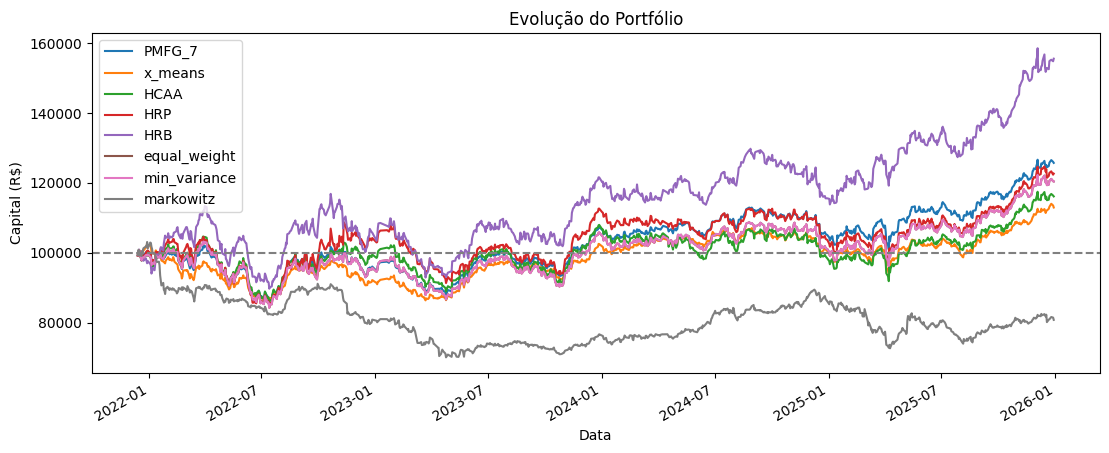

In [17]:
# setando uma quantidade inicial de capital para invstimento
CAPITAL_INICIAL = 100_000

# transformando os retornos logaritmicos em retornos simples para calculo do retorno cumulativo
portfolio_returns = portfolio_returns.astype(float)
simple_returns = np.exp(portfolio_returns) - 1
# calculo do retorno cumulativo levando em consideração o capital inicial
cumulative_returns = (1 + simple_returns).cumprod() * CAPITAL_INICIAL
import matplotlib.pyplot as plt

# plotando a evolução do portfolio no tempo
(cumulative_returns ).plot(figsize=(13, 5))

plt.axhline(y=CAPITAL_INICIAL, color='gray', linestyle='--', linewidth=1.5)
plt.title('Evolução do Portfólio')
plt.xlabel("Data")
plt.ylabel("Capital (R$)") 
plt.show()

In [24]:
oos_results

,AV,SD,SR,ASR,SO,TO,SSPW
X_Means,0.032098,0.092847,0.345706,0.345627,0.491429,0.096121,0.071329
HCAA,0.039399,0.132775,0.296732,0.296691,0.422562,0.149457,0.083494
HRP,0.053798,0.149736,0.359284,0.359753,0.530248,0.067468,0.503350
HRB,0.116417,0.167306,0.695834,0.695214,1.002193,0.005980,0.052175
PMFG_7,0.060318,0.113364,0.532078,0.531996,0.767339,0.270412,0.083411
equal_weight,0.048930,0.130261,0.375630,0.375626,0.539876,0.000078,0.047619
min_variance,0.048930,0.130261,0.375630,0.375626,0.539876,0.000078,0.047619
min_variance,-0.056252,0.115851,-0.485557,-0.486532,-0.642065,0.285187,0.396249


##### Calculando indicadores de performance

In [21]:
# Adicionando o índice de mercado (IBOV)
benchmarks = ['^BVSP']
data = yf.download(benchmarks, start="2020-01-02", end="2026-01-01", auto_adjust=True, progress=False)['Close']

# Calcular retornos diários
returns = data.pct_change().dropna()
returns = returns.reindex(portfolio_returns.index).dropna()

# Taxa livre de risco diária — usar 0 para ser comparável com oos_results
# (trocar por ex. 0.1175 / 252 para usar a Selic atual)
risk_free_rate = 0# 0.06 / 252

# Funções para calcular os indicadores — todas retornam valores anualizados
def sharpe_ratio(returns, risk_free_rate):
    excess = returns - risk_free_rate
    return np.sqrt(252) * np.mean(excess) / np.std(excess, ddof=1)

def sortino_ratio(returns, risk_free_rate):
    excess = returns - risk_free_rate
    downside = excess[excess < 0]
    downside_std = np.sqrt(np.mean(downside ** 2)) if len(downside) > 0 else np.nan
    return np.sqrt(252) * np.mean(excess) / downside_std if (downside_std and downside_std != 0) else np.nan

def jensen_alpha(portfolio_returns, market_returns, risk_free_rate):
    p, m = portfolio_returns.values, market_returns.values
    beta = np.cov(p, m)[0, 1] / np.var(m)
    # alpha diário anualizado
    alpha_daily = np.mean(p) - (risk_free_rate + beta * (np.mean(m) - risk_free_rate))
    return 252 * alpha_daily

def treynor_ratio(portfolio_returns, market_returns, risk_free_rate):
    p, m = portfolio_returns.values, market_returns.values
    beta = np.cov(p, m)[0, 1] / np.var(m)
    excess_annual = 252 * (np.mean(p) - risk_free_rate)
    return excess_annual / beta if beta != 0 else np.nan

def information_ratio(portfolio_returns, market_returns):
    excess = portfolio_returns - market_returns
    return np.sqrt(252) * np.mean(excess) / np.std(excess, ddof=1)

def calmar_ratio(returns, risk_free_rate, max_drawdown):
    annual_excess = 252 * np.mean(returns - risk_free_rate)
    return annual_excess / abs(max_drawdown) if max_drawdown != 0 else np.nan

def sterling_ratio(returns, risk_free_rate, avg_drawdown):
    annual_excess = 252 * np.mean(returns - risk_free_rate)
    return annual_excess / abs(avg_drawdown) if avg_drawdown != 0 else np.nan

def omega_ratio(returns, threshold=0):
    gains  = (returns[returns >  threshold] - threshold).sum()
    losses = (threshold - returns[returns <= threshold]).sum()
    return gains / losses if losses != 0 else np.nan

def upside_potential_ratio(returns, threshold=0):
    upside       = (returns[returns > threshold] - threshold).mean()
    downside_std = np.sqrt(np.mean(np.minimum(returns - threshold, 0) ** 2))
    return upside / downside_std if downside_std != 0 else np.nan

# Função para calcular todos os indicadores para um portfólio
def calculate_indicators(portfolio_returns, market_returns, risk_free_rate):
    portfolio_returns = portfolio_returns.astype(float)
    market_returns    = market_returns.astype(float)
    # alinha os dois pelo índice comum (após pct_change o portfolio perde 1 linha)
    portfolio_returns, market_returns = portfolio_returns.align(market_returns, join='inner')
    portfolio_returns = portfolio_returns.dropna()
    market_returns    = market_returns.loc[portfolio_returns.index]

    # drawdown calculado sobre a riqueza acumulada
    cumulative    = (1 + portfolio_returns).cumprod()
    max_cum       = cumulative.cummax()
    drawdown      = (cumulative - max_cum) / max_cum
    max_drawdown  = drawdown.min()
    avg_drawdown  = drawdown[drawdown < 0].mean()   # média só dos períodos negativos

    indicators = {
        'Sharpe Ratio':          sharpe_ratio(portfolio_returns, risk_free_rate),
        'Sortino Ratio':         sortino_ratio(portfolio_returns, risk_free_rate),
        "Jensen's Alpha":        jensen_alpha(portfolio_returns, market_returns, risk_free_rate),
        'Treynor Ratio':         treynor_ratio(portfolio_returns, market_returns, risk_free_rate),
        'Information Ratio':     information_ratio(portfolio_returns, market_returns),
        'Calmar Ratio':          calmar_ratio(portfolio_returns, risk_free_rate, max_drawdown),
        'Sterling Ratio':        sterling_ratio(portfolio_returns, risk_free_rate, avg_drawdown),
        'Omega Ratio':           omega_ratio(portfolio_returns),
        'Upside Potential Ratio':upside_potential_ratio(portfolio_returns),
    }

    return indicators

# Calculando os indicadores para cada portfólio
results = {}
cumulative_returns_dict = {}
for portfolio in portfolio_returns.columns.tolist():
    portfolio_returns_ = portfolio_returns[portfolio]
    market_returns = returns[benchmarks[0]]
    results[portfolio] = calculate_indicators(portfolio_returns_, market_returns, risk_free_rate)
    cumulative_returns_dict[portfolio] = (1 + portfolio_returns_).cumprod()

# Convertendo os resultados em um DataFrame para comparação
results_df = pd.DataFrame(results).T

In [22]:
results_df

,Sharpe Ratio,Sortino Ratio,Jensen's Alpha,Treynor Ratio,Information Ratio,Calmar Ratio,Sterling Ratio,Omega Ratio,Upside Potential Ratio
PMFG_7,0.532078,0.525599,-0.014935,0.099869,-0.761352,0.381737,1.361065,1.092045,1.080381
x_means,0.345706,0.345124,-0.015137,0.084668,-0.746866,0.198436,0.521941,1.059020,1.096054
HCAA,0.296732,0.294551,-0.044392,0.058585,-0.945808,0.213814,0.607669,1.049929,1.088787
HRP,0.359284,0.370806,-0.040684,0.070944,-0.783819,0.273320,0.873604,1.063163,1.100321
HRB,0.695834,0.691796,-0.008331,0.116275,-0.480872,0.546022,1.694134,1.121742,1.111165
equal_weight,0.375630,0.374298,-0.037195,0.070786,-0.944595,0.261079,0.866807,1.064018,1.088416
min_variance,0.375630,0.374298,-0.037195,0.070786,-0.944595,0.261079,0.866807,1.064018,1.088416
markowitz,-0.485557,-0.448039,-0.083103,-0.261024,-1.058505,-0.171852,-0.247645,0.919076,0.895327


In [39]:
idx = oos_results.index.tolist()
idx[-1] = 'markowitz'
idx[0] = 'x_means'
oos_results.index = idx
oos_results_ = oos_results.reindex(results_df.index)
oos_results_
results_df['SD'] = oos_results_['SD']
results_df['TO'] = oos_results_['TO']
results_df['SSPW'] = oos_results_['SSPW']
results_df

,Sharpe Ratio,Sortino Ratio,Jensen's Alpha,Treynor Ratio,Information Ratio,Calmar Ratio,Sterling Ratio,Omega Ratio,Upside Potential Ratio,SD,TO,SSPW
PMFG_7,0.532078,0.525599,-0.014935,0.099869,-0.761352,0.381737,1.361065,1.092045,1.080381,0.113364,0.270412,0.083411
x_means,0.345706,0.345124,-0.015137,0.084668,-0.746866,0.198436,0.521941,1.059020,1.096054,0.092847,0.096121,0.071329
HCAA,0.296732,0.294551,-0.044392,0.058585,-0.945808,0.213814,0.607669,1.049929,1.088787,0.132775,0.149457,0.083494
HRP,0.359284,0.370806,-0.040684,0.070944,-0.783819,0.273320,0.873604,1.063163,1.100321,0.149736,0.067468,0.503350
HRB,0.695834,0.691796,-0.008331,0.116275,-0.480872,0.546022,1.694134,1.121742,1.111165,0.167306,0.005980,0.052175
equal_weight,0.375630,0.374298,-0.037195,0.070786,-0.944595,0.261079,0.866807,1.064018,1.088416,0.130261,0.000078,0.047619
min_variance,0.375630,0.374298,-0.037195,0.070786,-0.944595,0.261079,0.866807,1.064018,1.088416,0.130261,0.000078,0.047619
markowitz,-0.485557,-0.448039,-0.083103,-0.261024,-1.058505,-0.171852,-0.247645,0.919076,0.895327,0.115851,0.285187,0.396249
